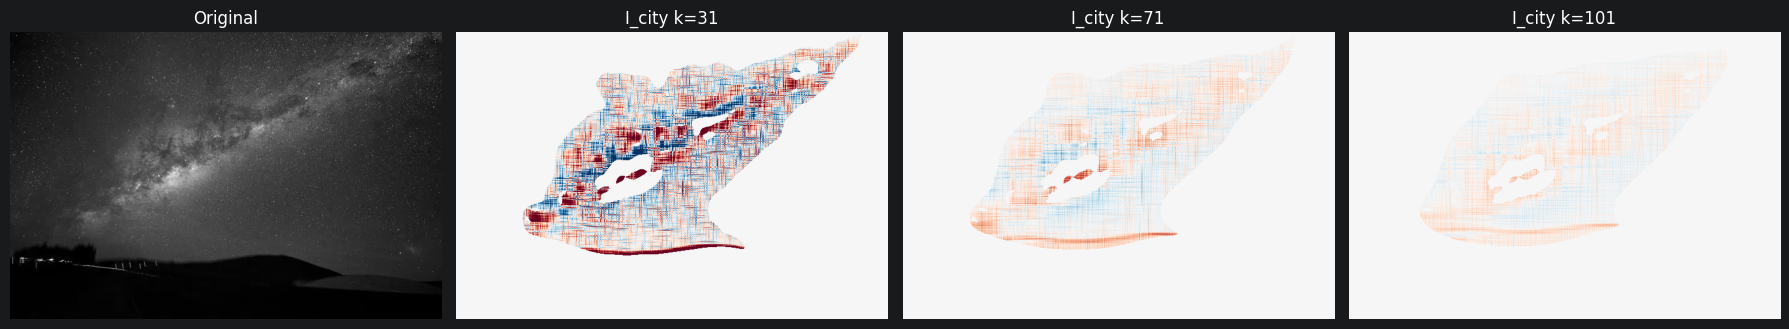

In [2]:
import torch
import numpy as np
import torch.nn.functional as F_conv
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

import pinn_starlight_core.data.PhotoLoader as Loader

# --- 数据 ---
loader = Loader.RAWLoader()
loader.load(r"../../data/real_raw/origin/03.jpg")
gray = np.mean(loader.rgb_data, axis=2).astype(np.float32)
H, W = gray.shape
img = torch.from_numpy(gray)[None, None]   # (1, 1, H, W)

# --- 共享常量 ---
LAP_KERNEL = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]])
y_axis = torch.linspace(0, 1, H)
DECAY = (1 - torch.exp(-y_axis * 6))[:, None]   # (H, 1) → broadcast 到 (H, W)

# 边缘 mask 只算一次 (基于小 kernel 的 blur, 边缘更锐利)
blur_ref = F.gaussian_blur(img, [31, 31], sigma=[10.0, 10.0]).squeeze()
gy, gx = torch.gradient(blur_ref)
grad_mag = torch.sqrt(gx**2 + gy**2)
EDGE_MASK = (grad_mag < grad_mag.quantile(0.95)).float()

# --- 跑三个 kernel ---
results = []
for ks in [31, 71, 101]:
    blur = F.gaussian_blur(img, [ks, ks], sigma=[ks/3.0, ks/3.0]).squeeze()
    lap = F_conv.conv2d(blur[None, None], LAP_KERNEL.view(1, 1, 3, 3), padding=1).squeeze()
    bright_mask = (blur > blur.quantile(0.70)).float()
    I_city = lap * bright_mask * DECAY * EDGE_MASK
    results.append((ks, I_city))

# --- 显示 ---
vlim = max(np.percentile(ic.abs().numpy(), 98) for _, ic in results)

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title('Original')
for i, (ks, ic) in enumerate(results):
    ax[i+1].imshow(ic, cmap='RdBu', vmin=-vlim, vmax=vlim)
    ax[i+1].set_title(f'I_city k={ks}')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()